# Layer 6: Failure Risk Scoring Engine

## Maintenance Intelligence and Operational Decision Support

**Business Goal:** Build a Failure Risk Scoring Engine for maintenance planning.  
**Data Source:** SQLite database `maintenance.db`  
**Tables Used:** `machine_clean`, `machine_analytics`  
**Target:** `machine_failure`

This notebook is framed as a maintenance analytics solution. The objective is not to showcase machine learning complexity; the objective is to identify high-risk operating conditions and support preventive maintenance decisions before equipment failure.

## Section 1: Business Purpose and Risk Scoring Approach

### Business Purpose

Maintenance teams need a practical way to prioritize equipment observations that show elevated failure risk. A risk scoring engine converts operating conditions into a failure probability and a clear action category.

### Methodology

- Read clean and analytics-ready machine records from SQLite.
- Use existing engineered features from `machine_analytics`.
- Train a Logistic Regression model to estimate failure probability.
- Convert probabilities into Low, Medium, and High Risk categories.
- Produce a risk scoring table with recommended maintenance actions.

### Why Logistic Regression Was Chosen

- It produces probability outputs that are useful for maintenance risk scoring.
- It is interpretable enough for operations and reliability stakeholders.
- Coefficients can be translated into business insight about risk drivers.
- It is suitable as a first production baseline before more complex models are considered.

### Results

This notebook will produce failure probabilities, risk categories, model evaluation metrics, feature importance, and a maintenance action table.

### Insight

A transparent model is easier to operationalize because maintenance leaders can understand why a machine is being flagged.

### Recommendation

Use this scoring engine as a baseline decision-support layer and validate risk thresholds with maintenance managers before production deployment.

In [1]:
from __future__ import annotations

import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATABASE_PATH = PROJECT_ROOT / "data" / "database" / "maintenance.db"
print(f"Database path: {DATABASE_PATH}")

Database path: C:\Users\Lavanya\Documents\Data analytics\Industrial Equipment Performance & Maintenance Intelligence Analytics Platform\data\database\maintenance.db


In [2]:
def require_database(path: Path) -> None:
    if not path.exists():
        raise FileNotFoundError(
            f"Database not found at {path}. Run Layer 1 ingestion or Layer 3 cleaning before this risk scoring notebook."
        )

def run_sql(query: str) -> pd.DataFrame:
    with sqlite3.connect(DATABASE_PATH) as connection:
        return pd.read_sql_query(query, connection)

def validate_required_tables() -> None:
    required_tables = {"machine_clean", "machine_analytics"}
    with sqlite3.connect(DATABASE_PATH) as connection:
        existing_tables = {
            row[0]
            for row in connection.execute(
                "SELECT name FROM sqlite_master WHERE type IN ('table', 'view');"
            ).fetchall()
        }
    missing = sorted(required_tables - existing_tables)
    if missing:
        raise ValueError(f"Missing required database tables: {missing}")

def annotate_bars(ax, values, fmt="{:.2f}", offset_ratio=0.02) -> None:
    if len(values) == 0:
        return
    max_value = max(values) if max(values) != 0 else 1
    for patch, value in zip(ax.patches, values):
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + max_value * offset_ratio,
            fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=9,
        )

require_database(DATABASE_PATH)
validate_required_tables()

## Section 2: SQLite Data Source and Feature Selection

### Business Purpose

The scoring engine must use the governed database tables as the single source of truth. This keeps the model aligned with SQL analytics, KPI reporting, and Power BI datasets.

### Methodology

Data is read directly from `machine_clean` and `machine_analytics`. Existing engineered features are reused from `machine_analytics` and are not recreated in this notebook.

### Feature Selection Decision

The model uses pre-failure operating condition features:

- Air temperature
- Process temperature
- Temperature difference
- Rotational speed
- Torque
- Tool wear
- Mechanical power
- Operating stress score
- Machine type

`failure_mode_count` and `primary_failure_mode` are reused for business interpretation, but they are not used as model inputs because they are failure outcome signals and would create target leakage.

### Results

The query below creates the modeling dataset from SQLite.

### Insight

Using only operating-condition features makes the score more useful for early maintenance planning.

### Recommendation

Keep failure outcome fields out of model training, but use them for post-score validation and executive interpretation.

In [3]:
risk_data_sql = """
SELECT
    mc.observation_id AS machine_id,
    mc.product_id,
    mc.machine_type,
    ma.air_temperature_k AS air_temperature,
    ma.process_temperature_k AS process_temperature,
    ma.temperature_difference_k AS temperature_difference,
    ma.rotational_speed_rpm AS rotational_speed,
    ma.torque_nm AS torque,
    ma.tool_wear_min AS tool_wear,
    ma.mechanical_power_watts AS mechanical_power,
    ma.tool_wear_risk_level AS tool_wear_risk_category,
    ma.operating_stress_score,
    ma.failure_mode_count AS failure_count,
    ma.primary_failure_mode,
    mc.machine_failure
FROM machine_clean AS mc
INNER JOIN machine_analytics AS ma
    ON mc.observation_id = ma.observation_id;
"""
risk_df = run_sql(risk_data_sql)
display(risk_df.head())
print(f"Rows loaded from SQLite: {len(risk_df):,}")

,machine_id,product_id,machine_type,air_temperature,process_temperature,temperature_difference,rotational_speed,torque,tool_wear,mechanical_power,tool_wear_risk_category,operating_stress_score,failure_count,primary_failure_mode,machine_failure
0,1,M14860,M,298.1,308.6,10.5,1551,42.8,0,6951.5906,Low,45.0679,0,No Failure,0
1,2,L47181,L,298.2,308.7,10.5,1408,46.3,3,6826.7227,Low,46.2314,0,No Failure,0
2,3,L47182,L,298.1,308.5,10.4,1498,49.4,5,7749.3875,Low,49.4126,0,No Failure,0
3,4,L47183,L,298.2,308.6,10.4,1433,39.5,7,5927.5047,Low,41.3242,0,No Failure,0
4,5,L47184,L,298.2,308.7,10.5,1408,40.0,9,5897.8166,Low,42.1695,0,No Failure,0


Rows loaded from SQLite: 10,000


In [4]:
target_summary_df = pd.DataFrame(
    {
        "machine_failure": risk_df["machine_failure"].value_counts().index,
        "observation_count": risk_df["machine_failure"].value_counts().values,
    }
).sort_values("machine_failure")
target_summary_df["share_percent"] = (100 * target_summary_df["observation_count"] / len(risk_df)).round(4)
display(target_summary_df)

feature_columns = [
    "air_temperature",
    "process_temperature",
    "temperature_difference",
    "rotational_speed",
    "torque",
    "tool_wear",
    "mechanical_power",
    "operating_stress_score",
    "machine_type",
]
numeric_features = [column for column in feature_columns if column != "machine_type"]
categorical_features = ["machine_type"]

X = risk_df[feature_columns].copy()
y = risk_df["machine_failure"].astype(int)

print(f"Selected model features: {feature_columns}")

,machine_failure,observation_count,share_percent
0,0,9661,96.61
1,1,339,3.39


Selected model features: ['air_temperature', 'process_temperature', 'temperature_difference', 'rotational_speed', 'torque', 'tool_wear', 'mechanical_power', 'operating_stress_score', 'machine_type']


## Section 3: Preprocessing and Train/Test Split

### Business Purpose

Preprocessing ensures that operating signals are prepared consistently before scoring. This improves reliability of the risk engine and makes future production scoring repeatable.

### Methodology

- Numeric operating fields are scaled because Logistic Regression is sensitive to feature scale.
- `machine_type` is one-hot encoded because it is categorical.
- A stratified train/test split preserves the failure/non-failure balance in both datasets.
- `class_weight='balanced'` is used because machine failures are expected to be a minority class.

### Results

The pipeline below handles encoding, scaling, and Logistic Regression training in one repeatable workflow.

### Insight

The preprocessing choices are designed for operational consistency, not model complexity.

### Recommendation

Use the same pipeline structure for future scoring so maintenance risk scores remain consistent over time.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ]
)

risk_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="liblinear",
                random_state=42,
            ),
        ),
    ]
)

split_summary_df = pd.DataFrame(
    {
        "dataset": ["Train", "Test"],
        "observations": [len(X_train), len(X_test)],
        "failure_count": [int(y_train.sum()), int(y_test.sum())],
        "failure_rate_percent": [round(100 * y_train.mean(), 4), round(100 * y_test.mean(), 4)],
    }
)
display(split_summary_df)

,dataset,observations,failure_count,failure_rate_percent
0,Train,7500,254,3.3867
1,Test,2500,85,3.4000


## Section 4: Model Training and Failure Probability Output

### Business Purpose

The model converts current operating conditions into a probability of failure. This probability is the core score used for maintenance prioritization.

### Methodology

A Logistic Regression model is trained on historical operating observations and the `machine_failure` target. The model outputs a probability between `0` and `1` for each observation.

### Results

The model generates failure probabilities for the test set and the full dataset.

### Insight

Probability scoring allows maintenance leaders to rank machines by risk instead of treating all machines equally.

### Recommendation

Use probability scores as a prioritization layer, then combine them with maintenance expertise and current operating context.

In [6]:
risk_model.fit(X_train, y_train)

test_failure_probability = risk_model.predict_proba(X_test)[:, 1]
test_predictions = risk_model.predict(X_test)

risk_df["failure_probability"] = risk_model.predict_proba(X)[:, 1]

probability_summary_df = risk_df["failure_probability"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame("failure_probability")
display(probability_summary_df)

,failure_probability
count,10000.000000
mean,0.235867
std,0.262799
min,0.001584
10%,0.014880
25%,0.038892
50%,0.122167
75%,0.346733
90%,0.685045
max,0.999987


## Section 5: Risk Categories and Threshold Justification

### Business Purpose

Maintenance teams need action categories, not only model probabilities. Risk categories convert probability into operational guidance.

### Methodology

The thresholds are intentionally conservative because machine failures are rare but operationally expensive.

| Risk Category | Failure Probability Threshold | Recommended Meaning |
|---|---:|---|
| Low Risk | `< 0.15` | Continue standard monitoring. |
| Medium Risk | `0.15 to < 0.35` | Review operating condition and schedule inspection if risk persists. |
| High Risk | `>= 0.35` | Prioritize preventive maintenance review. |

### Results

Each machine observation receives a risk category and recommended action.

### Insight

A lower High Risk threshold is appropriate for rare-event maintenance analytics because waiting for very high probabilities can miss preventable failures.

### Recommendation

Validate these thresholds with maintenance managers and adjust based on downtime cost, technician capacity, and false alarm tolerance.

In [7]:
def assign_risk_category(probability: float) -> str:
    if probability >= 0.35:
        return "High Risk"
    if probability >= 0.15:
        return "Medium Risk"
    return "Low Risk"

def recommended_action(risk_category: str) -> str:
    if risk_category == "High Risk":
        return "Prioritize preventive maintenance inspection and review operating conditions immediately."
    if risk_category == "Medium Risk":
        return "Monitor closely and schedule inspection if elevated risk persists."
    return "Continue standard monitoring and routine maintenance cadence."

risk_df["risk_category"] = risk_df["failure_probability"].apply(assign_risk_category)
risk_df["recommended_action"] = risk_df["risk_category"].apply(recommended_action)

risk_distribution_df = (
    risk_df.groupby("risk_category", as_index=False)
    .agg(
        observation_count=("machine_id", "count"),
        actual_failures=("machine_failure", "sum"),
        avg_failure_probability=("failure_probability", "mean"),
        actual_failure_rate=("machine_failure", "mean"),
    )
)
risk_distribution_df["observation_share_percent"] = (100 * risk_distribution_df["observation_count"] / len(risk_df)).round(4)
risk_distribution_df["avg_failure_probability"] = risk_distribution_df["avg_failure_probability"].round(4)
risk_distribution_df["actual_failure_rate_percent"] = (100 * risk_distribution_df["actual_failure_rate"]).round(4)
risk_distribution_df = risk_distribution_df.drop(columns="actual_failure_rate")
risk_distribution_df = risk_distribution_df.sort_values(
    "risk_category",
    key=lambda values: values.map({"High Risk": 1, "Medium Risk": 2, "Low Risk": 3}),
)
display(risk_distribution_df)

,risk_category,observation_count,actual_failures,avg_failure_probability,observation_share_percent,actual_failure_rate_percent
0,High Risk,2485,305,0.6362,24.85,12.2736
2,Medium Risk,2054,22,0.2348,20.54,1.0711
1,Low Risk,5461,12,0.0541,54.61,0.2197


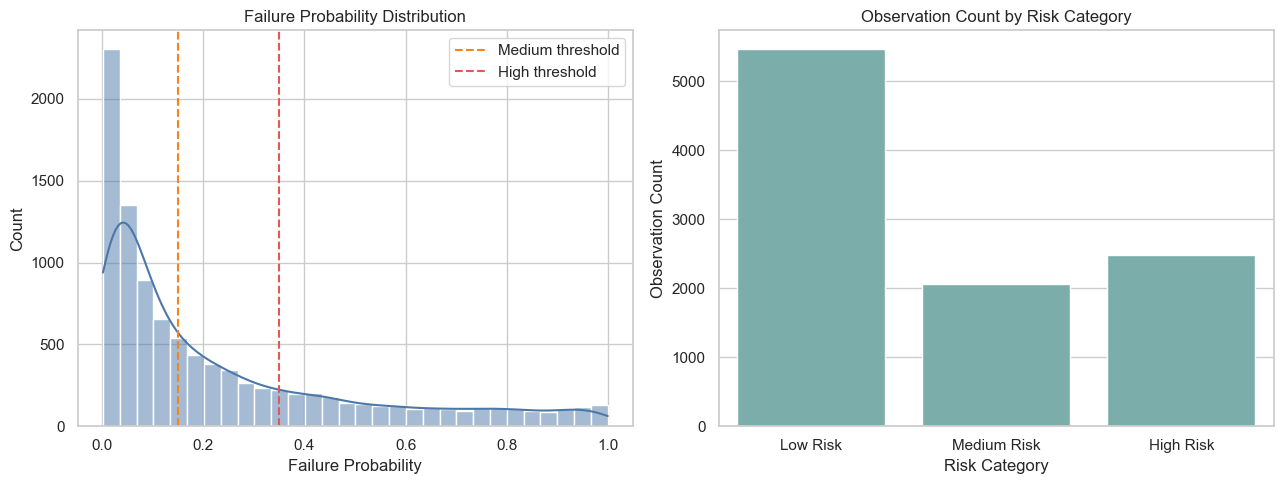

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(risk_df["failure_probability"], bins=30, kde=True, ax=axes[0], color="#4C78A8")
axes[0].axvline(0.15, color="#F58518", linestyle="--", label="Medium threshold")
axes[0].axvline(0.35, color="#E45756", linestyle="--", label="High threshold")
axes[0].set_title("Failure Probability Distribution")
axes[0].set_xlabel("Failure Probability")
axes[0].legend()

risk_order = ["Low Risk", "Medium Risk", "High Risk"]
sns.barplot(
    data=risk_distribution_df,
    x="risk_category",
    y="observation_count",
    order=risk_order,
    ax=axes[1],
    color="#72B7B2",
)
axes[1].set_title("Observation Count by Risk Category")
axes[1].set_xlabel("Risk Category")
axes[1].set_ylabel("Observation Count")
plt.tight_layout()
plt.show()

## Section 6: Model Evaluation

### Business Purpose

Evaluation determines whether the scoring engine is useful for maintenance planning. Recall is especially important because missed failures can lead to unplanned downtime.

### Methodology

The model is evaluated on a holdout test set using Accuracy, Precision, Recall, F1 Score, and ROC-AUC. A confusion matrix shows where the model correctly or incorrectly flags failures.

### Results

The metrics below summarize scoring engine performance.

### Insight

For maintenance risk scoring, a balanced view matters: high recall reduces missed failures, while precision controls unnecessary inspections.

### Recommendation

Review confusion matrix tradeoffs with maintenance leaders before changing risk thresholds.

In [9]:
metrics_df = pd.DataFrame(
    [
        {"metric": "Accuracy", "value": accuracy_score(y_test, test_predictions)},
        {"metric": "Precision", "value": precision_score(y_test, test_predictions, zero_division=0)},
        {"metric": "Recall", "value": recall_score(y_test, test_predictions, zero_division=0)},
        {"metric": "F1 Score", "value": f1_score(y_test, test_predictions, zero_division=0)},
        {"metric": "ROC-AUC", "value": roc_auc_score(y_test, test_failure_probability)},
    ]
)
metrics_df["value"] = metrics_df["value"].round(4)
display(metrics_df)

,metric,value
0,Accuracy,0.8576
1,Precision,0.1687
2,Recall,0.8118
3,F1 Score,0.2794
4,ROC-AUC,0.9142


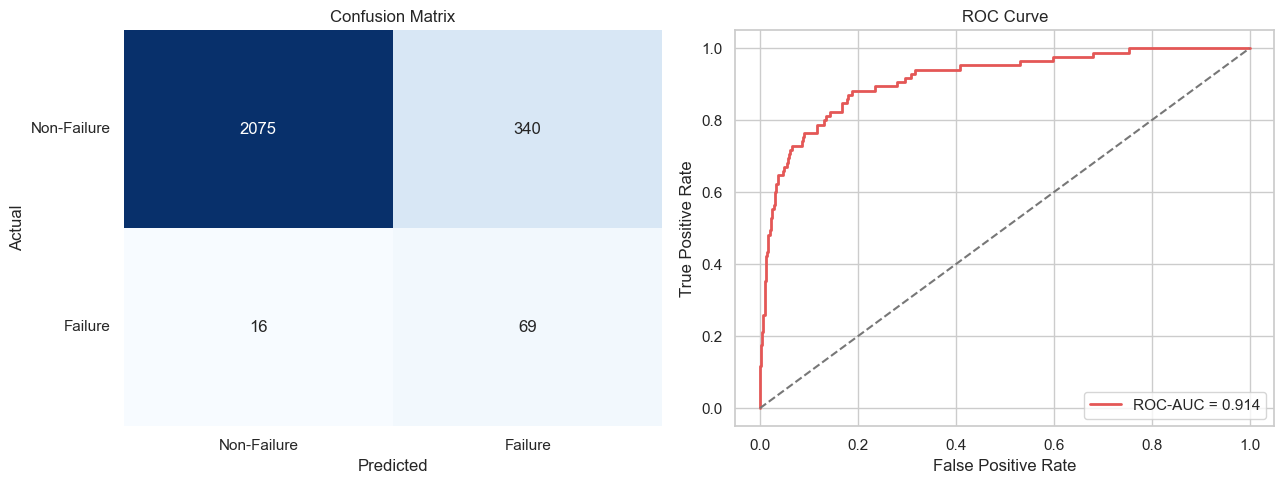

Insight
The evaluation metrics show how well the scoring engine separates failed and non-failed observations under the current feature set.
Recommendation
If recall is too low for maintenance tolerance, lower the High Risk threshold or add more condition-monitoring signals to the dataset.


In [10]:
cm = confusion_matrix(y_test, test_predictions)
fpr, tpr, thresholds = roc_curve(y_test, test_failure_probability)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticklabels(["Non-Failure", "Failure"])
axes[0].set_yticklabels(["Non-Failure", "Failure"], rotation=0)

axes[1].plot(fpr, tpr, color="#E45756", linewidth=2, label=f"ROC-AUC = {roc_auc_score(y_test, test_failure_probability):.3f}")
axes[1].plot([0, 1], [0, 1], color="#777777", linestyle="--")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print("Insight")
print("The evaluation metrics show how well the scoring engine separates failed and non-failed observations under the current feature set.")
print("Recommendation")
print("If recall is too low for maintenance tolerance, lower the High Risk threshold or add more condition-monitoring signals to the dataset.")

## Section 7: Feature Importance and Business Interpretation

### Business Purpose

Maintenance teams need to understand which factors contribute most to risk so they can act on the score.

### Methodology

Logistic Regression coefficients are extracted from the trained pipeline. Larger absolute coefficients indicate stronger contribution to the failure probability estimate.

### Results

The analysis focuses especially on Torque, Tool Wear, Temperature Difference, Mechanical Power, and Operating Stress.

### Insight

Feature importance translates the model from a score into a maintenance conversation about operating conditions.

### Recommendation

Use top drivers to build Power BI risk explanations and maintenance review checklists.

In [11]:
encoded_categorical_names = risk_model.named_steps["preprocessor"].named_transformers_["categorical"].get_feature_names_out(categorical_features).tolist()
model_feature_names = numeric_features + encoded_categorical_names
coefficients = risk_model.named_steps["model"].coef_[0]

feature_importance_df = pd.DataFrame(
    {
        "feature": model_feature_names,
        "coefficient": coefficients,
        "absolute_coefficient": np.abs(coefficients),
        "risk_direction": np.where(coefficients >= 0, "Increases failure risk", "Reduces failure risk"),
    }
).sort_values("absolute_coefficient", ascending=False)

display(feature_importance_df)

,feature,coefficient,absolute_coefficient,risk_direction
4,torque,6.631998,6.631998,Increases failure risk
6,mechanical_power,-4.062304,4.062304,Reduces failure risk
3,rotational_speed,2.390129,2.390129,Increases failure risk
2,temperature_difference,-1.089369,1.089369,Reduces failure risk
7,operating_stress_score,0.803551,0.803551,Increases failure risk
5,tool_wear,0.533173,0.533173,Increases failure risk
0,air_temperature,0.361314,0.361314,Increases failure risk
1,process_temperature,-0.246162,0.246162,Reduces failure risk
8,machine_type_L,0.209753,0.209753,Increases failure risk
9,machine_type_M,-0.122928,0.122928,Reduces failure risk


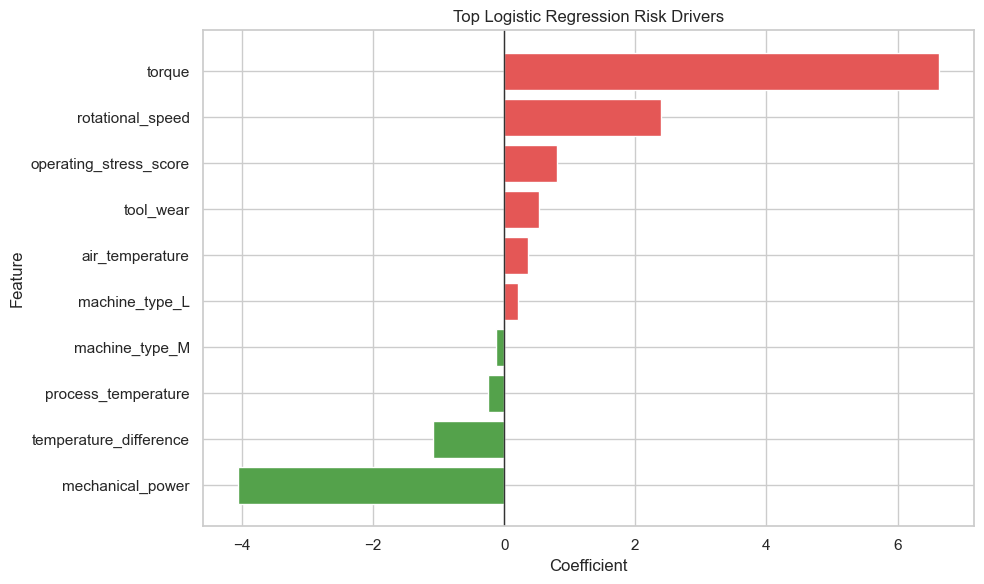

,feature,coefficient,absolute_coefficient,risk_direction
4,torque,6.631998,6.631998,Increases failure risk
6,mechanical_power,-4.062304,4.062304,Reduces failure risk
2,temperature_difference,-1.089369,1.089369,Reduces failure risk
7,operating_stress_score,0.803551,0.803551,Increases failure risk
5,tool_wear,0.533173,0.533173,Increases failure risk


Insight
The strongest risk driver by absolute coefficient is torque, with direction: Increases failure risk.
Recommendation
Use the strongest positive drivers as early warning indicators and review them during preventive maintenance planning meetings.


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance_df.head(10).sort_values("coefficient")
colors = np.where(top_features["coefficient"] >= 0, "#E45756", "#54A24B")
ax.barh(top_features["feature"], top_features["coefficient"], color=colors)
ax.axvline(0, color="#333333", linewidth=1)
ax.set_title("Top Logistic Regression Risk Drivers")
ax.set_xlabel("Coefficient")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

focus_features = ["torque", "tool_wear", "temperature_difference", "mechanical_power", "operating_stress_score"]
focus_feature_importance_df = feature_importance_df.loc[feature_importance_df["feature"].isin(focus_features)]
display(focus_feature_importance_df)

top_driver = feature_importance_df.iloc[0]
print("Insight")
print(f"The strongest risk driver by absolute coefficient is {top_driver['feature']}, with direction: {top_driver['risk_direction']}.")
print("Recommendation")
print("Use the strongest positive drivers as early warning indicators and review them during preventive maintenance planning meetings.")

## Section 8: Business Insights From the Risk Engine

### Business Purpose

This section converts model output into maintenance decisions by answering four operating questions.

### Methodology

Risk categories, failure probabilities, and operating conditions are summarized to identify the strongest indicators, high-risk conditions, priority machines, and early warning signals.

### Results

The tables below translate risk scoring into action-oriented maintenance intelligence.

### Insight

Risk scoring is most valuable when paired with clear operating condition patterns.

### Recommendation

Use this section as the starting point for preventive maintenance rules and Power BI exception pages.

In [13]:
strongest_indicators_df = feature_importance_df.loc[
    feature_importance_df["risk_direction"] == "Increases failure risk"
].head(8)
display(strongest_indicators_df)

high_risk_conditions_df = (
    risk_df.groupby("risk_category", as_index=False)
    .agg(
        avg_failure_probability=("failure_probability", "mean"),
        avg_torque=("torque", "mean"),
        avg_tool_wear=("tool_wear", "mean"),
        avg_temperature_difference=("temperature_difference", "mean"),
        avg_mechanical_power=("mechanical_power", "mean"),
        avg_operating_stress_score=("operating_stress_score", "mean"),
        actual_failure_rate=("machine_failure", "mean"),
    )
)
for column in high_risk_conditions_df.columns:
    if column.startswith("avg_") or column == "actual_failure_rate":
        high_risk_conditions_df[column] = high_risk_conditions_df[column].round(4)
high_risk_conditions_df["actual_failure_rate_percent"] = (100 * high_risk_conditions_df["actual_failure_rate"]).round(4)
display(high_risk_conditions_df.drop(columns="actual_failure_rate"))

,feature,coefficient,absolute_coefficient,risk_direction
4,torque,6.631998,6.631998,Increases failure risk
3,rotational_speed,2.390129,2.390129,Increases failure risk
7,operating_stress_score,0.803551,0.803551,Increases failure risk
5,tool_wear,0.533173,0.533173,Increases failure risk
0,air_temperature,0.361314,0.361314,Increases failure risk
8,machine_type_L,0.209753,0.209753,Increases failure risk


,risk_category,avg_failure_probability,avg_torque,avg_tool_wear,avg_temperature_difference,avg_mechanical_power,avg_operating_stress_score,actual_failure_rate_percent
0,High Risk,0.6362,47.8392,147.2221,9.4693,7071.5980,55.9420,12.27
1,Low Risk,0.0541,36.0679,81.8356,10.3481,5878.5957,47.1209,0.22
2,Medium Risk,0.2348,40.9065,129.8729,9.7196,6388.2752,51.4044,1.07


In [14]:
priority_machines_df = risk_df.sort_values("failure_probability", ascending=False)[
    [
        "machine_id",
        "product_id",
        "machine_type",
        "failure_probability",
        "risk_category",
        "tool_wear_risk_category",
        "operating_stress_score",
        "torque",
        "tool_wear",
        "mechanical_power",
        "recommended_action",
    ]
].head(20)
priority_machines_df["failure_probability"] = priority_machines_df["failure_probability"].round(4)
display(priority_machines_df)

warning_thresholds = {
    "torque": risk_df["torque"].quantile(0.75),
    "tool_wear": risk_df["tool_wear"].quantile(0.75),
    "temperature_difference": risk_df["temperature_difference"].quantile(0.75),
    "mechanical_power": risk_df["mechanical_power"].quantile(0.75),
    "operating_stress_score": risk_df["operating_stress_score"].quantile(0.75),
}

early_warning_rows = []
for feature, threshold in warning_thresholds.items():
    subset = risk_df.loc[risk_df[feature] >= threshold]
    early_warning_rows.append(
        {
            "early_warning_signal": f"High {feature}",
            "threshold_used": round(threshold, 4),
            "observations_above_threshold": len(subset),
            "avg_failure_probability": round(subset["failure_probability"].mean(), 4),
            "actual_failure_rate_percent": round(100 * subset["machine_failure"].mean(), 4),
        }
    )
early_warning_df = pd.DataFrame(early_warning_rows).sort_values("avg_failure_probability", ascending=False)
display(early_warning_df)

,machine_id,product_id,machine_type,failure_probability,risk_category,tool_wear_risk_category,operating_stress_score,torque,tool_wear,mechanical_power,recommended_action
4296,4297,L51476,L,1.0000,High Risk,High,27.8981,5.8,215,1715.8332,Prioritize preventive maintenance inspection a...
50,51,L47230,L,0.9999,High Risk,Medium,29.4657,4.6,143,1378.1748,Prioritize preventive maintenance inspection a...
847,848,L48027,L,0.9999,High Risk,High,41.9301,5.6,213,1661.3580,Prioritize preventive maintenance inspection a...
1784,1785,L48964,L,0.9999,High Risk,Low,17.2991,3.8,57,1148.4406,Prioritize preventive maintenance inspection a...
463,464,L47643,L,0.9998,High Risk,Low,32.6631,4.2,118,1264.0512,Prioritize preventive maintenance inspection a...
4462,4463,L51642,L,0.9994,High Risk,Medium,63.5255,67.8,197,8967.2992,Prioritize preventive maintenance inspection a...
4383,4384,L51563,L,0.9992,High Risk,High,65.7258,65.5,229,8903.1689,Prioritize preventive maintenance inspection a...
5394,5395,M20254,M,0.9990,High Risk,High,78.4912,70.5,234,9317.0213,Prioritize preventive maintenance inspection a...
3584,3585,L50764,L,0.9989,High Risk,Medium,62.3486,68.9,135,8600.5078,Prioritize preventive maintenance inspection a...
4702,4703,L51882,L,0.9987,High Risk,Medium,59.4385,66.8,148,8548.2317,Prioritize preventive maintenance inspection a...


,early_warning_signal,threshold_used,observations_above_threshold,avg_failure_probability,actual_failure_rate_percent
0,High torque,46.8000,2501,0.5041,9.7961
3,High mechanical_power,7003.0027,2500,0.4829,8.9200
1,High tool_wear,162.0000,2543,0.4005,6.8030
4,High operating_stress_score,57.4240,2500,0.3850,6.6000
2,High temperature_difference,11.0000,2563,0.1205,2.1069


### Business Questions Answered

1. **Which variables are strongest failure indicators?**  
   The top positive Logistic Regression coefficients identify the strongest indicators. These should become candidate monitoring signals.

2. **Which operating conditions create the highest risk?**  
   High Risk records show the highest average failure probability and can be profiled by torque, tool wear, temperature difference, mechanical power, and operating stress.

3. **Which machines should be prioritized for preventive maintenance?**  
   The highest-probability records in the priority table should be reviewed first.

4. **What early warning signals appear before failures?**  
   High values in the strongest operating features can act as early warning candidates, especially when multiple signals are elevated together.

## Section 9: Risk Scoring Output Table

### Business Purpose

The final scoring table gives maintenance teams a concise action list with machine ID, failure probability, risk category, and recommended action.

### Methodology

The table is generated from the full SQLite-sourced dataset after scoring every observation with the trained Logistic Regression model.

### Results

The output table below is suitable for review, Power BI import, or future database publication.

### Insight

The highest-probability records are the most important starting point for preventive maintenance planning.

### Recommendation

Use the High Risk list for immediate review and the Medium Risk list for monitoring and follow-up scheduling.

In [15]:
risk_scoring_table = risk_df[
    ["machine_id", "failure_probability", "risk_category", "recommended_action"]
].copy()
risk_scoring_table["failure_probability"] = risk_scoring_table["failure_probability"].round(4)
risk_scoring_table = risk_scoring_table.sort_values("failure_probability", ascending=False)

display(risk_scoring_table.head(50))

print(f"Risk scoring table rows: {len(risk_scoring_table):,}")
print("Columns: Machine ID, Failure Probability, Risk Category, Recommended Action")

,machine_id,failure_probability,risk_category,recommended_action
4296,4297,1.0000,High Risk,Prioritize preventive maintenance inspection a...
1784,1785,0.9999,High Risk,Prioritize preventive maintenance inspection a...
50,51,0.9999,High Risk,Prioritize preventive maintenance inspection a...
847,848,0.9999,High Risk,Prioritize preventive maintenance inspection a...
463,464,0.9998,High Risk,Prioritize preventive maintenance inspection a...
4462,4463,0.9994,High Risk,Prioritize preventive maintenance inspection a...
4383,4384,0.9992,High Risk,Prioritize preventive maintenance inspection a...
5394,5395,0.9990,High Risk,Prioritize preventive maintenance inspection a...
3584,3585,0.9989,High Risk,Prioritize preventive maintenance inspection a...
4702,4703,0.9987,High Risk,Prioritize preventive maintenance inspection a...


Risk scoring table rows: 10,000
Columns: Machine ID, Failure Probability, Risk Category, Recommended Action


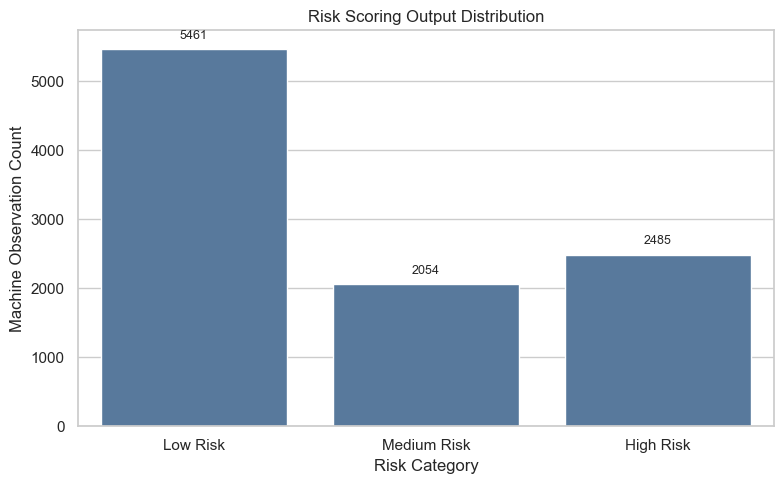

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
risk_counts = risk_scoring_table["risk_category"].value_counts().reindex(["Low Risk", "Medium Risk", "High Risk"]).fillna(0).reset_index()
risk_counts.columns = ["risk_category", "machine_count"]
sns.barplot(data=risk_counts, x="risk_category", y="machine_count", ax=ax, color="#4C78A8")
annotate_bars(ax, risk_counts["machine_count"].tolist(), fmt="{:.0f}")
ax.set_title("Risk Scoring Output Distribution")
ax.set_xlabel("Risk Category")
ax.set_ylabel("Machine Observation Count")
plt.tight_layout()
plt.show()

## Section 10: Executive Summary

### Business Purpose

Summarize the risk scoring engine in leadership terms: what was found, which conditions are high risk, what actions should be taken, and what business impact is expected.

### Methodology

The summary combines model performance, feature importance, risk distribution, high-risk operating profiles, and recommended actions.

### Results

The tables below provide executive-ready findings and actions.

### Insight

Risk scoring is most useful when it creates a short, ranked list of maintenance actions.

### Recommendation

Deploy the scoring output into Power BI or a maintenance planning workflow after threshold validation.

In [17]:
high_risk_count = int((risk_df["risk_category"] == "High Risk").sum())
medium_risk_count = int((risk_df["risk_category"] == "Medium Risk").sum())
roc_auc_value = float(metrics_df.loc[metrics_df["metric"] == "ROC-AUC", "value"].iloc[0])
recall_value = float(metrics_df.loc[metrics_df["metric"] == "Recall", "value"].iloc[0])

executive_summary_df = pd.DataFrame(
    {
        "Key Findings": [
            f"The scoring engine produced failure probabilities for {len(risk_df):,} machine observations.",
            f"{high_risk_count:,} observations are classified as High Risk and {medium_risk_count:,} as Medium Risk.",
            f"The holdout ROC-AUC is {roc_auc_value:.3f}, indicating the model's ability to separate failure and non-failure observations.",
            f"The holdout recall is {recall_value:.3f}, which is important for reducing missed failure events.",
            f"The strongest modeled risk driver is {top_driver['feature']}.",
        ],
        "High-Risk Conditions": [
            "Elevated failure probability based on operating conditions.",
            "High tool wear, elevated operating stress, or high mechanical load patterns.",
            "Operating signals above upper-quartile warning thresholds.",
            "Machine types and observations with concentrated high-risk scores.",
            "Combinations of torque, wear, temperature difference, power, and stress.",
        ],
        "Recommended Maintenance Actions": [
            "Review High Risk observations first for preventive maintenance inspection.",
            "Monitor Medium Risk observations and escalate if risk persists or increases.",
            "Use top risk drivers to guide technician checklists and operator review.",
            "Validate thresholds against downtime cost and maintenance capacity.",
            "Publish the scoring table to Power BI for maintenance planning visibility.",
        ],
        "Expected Business Impact": [
            "Improved prioritization of preventive maintenance activities.",
            "Earlier identification of operating conditions linked to failure risk.",
            "Reduced unplanned downtime exposure through risk-based inspection planning.",
            "More transparent maintenance decisions through interpretable probability scoring.",
            "Stronger foundation for future predictive maintenance deployment.",
        ],
    }
)
display(executive_summary_df)

,Key Findings,High-Risk Conditions,Recommended Maintenance Actions,Expected Business Impact
0,The scoring engine produced failure probabilit...,Elevated failure probability based on operatin...,Review High Risk observations first for preven...,Improved prioritization of preventive maintena...
1,"2,485 observations are classified as High Risk...","High tool wear, elevated operating stress, or ...",Monitor Medium Risk observations and escalate ...,Earlier identification of operating conditions...
2,"The holdout ROC-AUC is 0.914, indicating the m...",Operating signals above upper-quartile warning...,Use top risk drivers to guide technician check...,Reduced unplanned downtime exposure through ri...
3,"The holdout recall is 0.812, which is importan...",Machine types and observations with concentrat...,Validate thresholds against downtime cost and ...,More transparent maintenance decisions through...
4,The strongest modeled risk driver is torque.,"Combinations of torque, wear, temperature diff...",Publish the scoring table to Power BI for main...,Stronger foundation for future predictive main...


### Final Executive Commentary

The Failure Risk Scoring Engine provides a practical maintenance intelligence layer. It does not replace engineering judgment; it focuses attention on machines and operating conditions that deserve review first. The next step is to validate scoring thresholds with plant teams, connect the output to Power BI, and add real maintenance work-order data as the organization matures.